In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import joblib
from sklearn.base import clone
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [ ]:

model = joblib.load("../../../models/random_forest/linear_regression_model_v2.joblib")


In [38]:
df = pd.read_csv('../../../data/preprocessed/selected_features_onehot_encoded.csv')
df.head()

,Phsar_Chas_nearest,Royal_Palace_3_5km,h_id_price_min,n_atm_in_1km,n_atm_in_2km_to_3km,n_atm_in_3km_to_5km,nearest_resturant,address_line_2_Bak Kaeng,address_line_2_Boeng Kak Ti Muoy,address_line_2_Boeng Kak Ti Pir,...,h_id_886586a6c7fffff,h_id_886586a6d1fffff,h_id_886586a6d3fffff,h_id_886586a6d5fffff,h_id_886586a6d7fffff,h_id_886586a6d9fffff,h_id_886586a6dbfffff,h_id_886586a6ddfffff,h_id_886586a6ebfffff,price_per_m2
0,0,0,2879.39,10,50,497,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3357.98
1,0,1,2719.42,10,75,510,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3809.30
2,0,0,3166.66,10,72,502,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3437.03
3,0,1,3075.99,10,127,558,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3469.70
4,0,1,1880.12,0,35,524,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5442.34


In [39]:
X = df.drop('price_per_m2', axis=1)
y = df['price_per_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
params = model.get_params()
# params['early_stopping_rounds'] = None  # Disable early stopping for CV
# params['n_estimators'] = model.best_iteration  # Use optimal trees from training

model_for_cv = SVR(**params)

TypeError: SVR.__init__() got an unexpected keyword argument 'memory'

In [40]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100

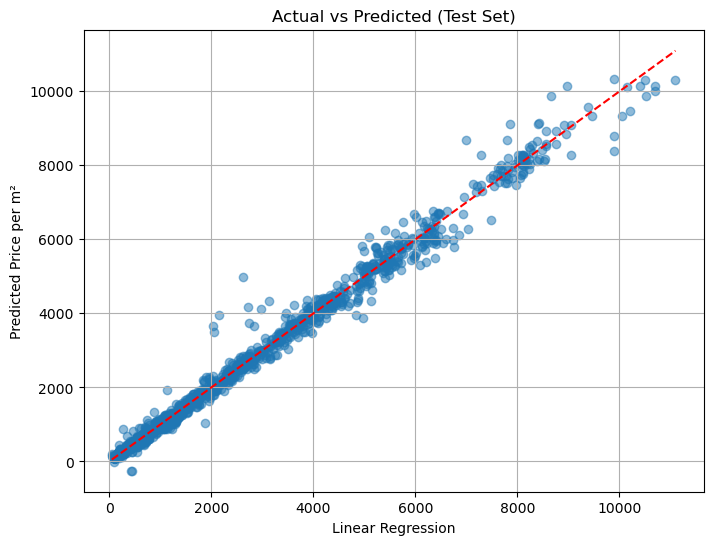

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Linear Regression")
plt.ylabel("Predicted Price per m²")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True)
plt.show()

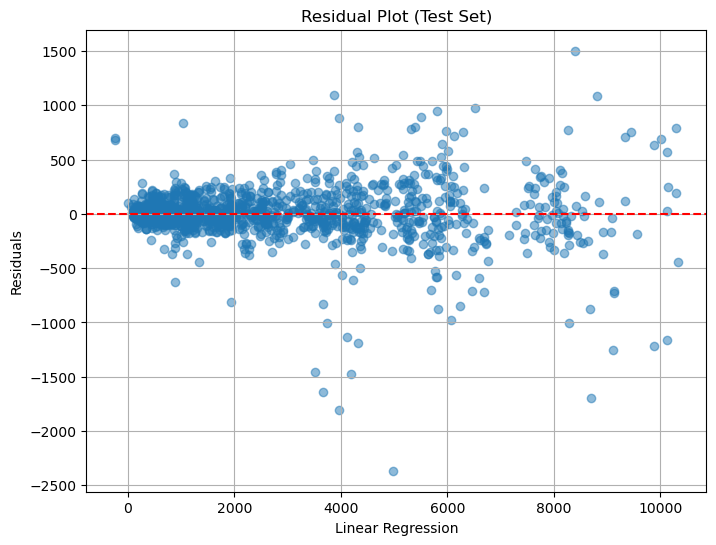

In [43]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Linear Regression")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")
plt.grid(True)
plt.show()

In [29]:
print("\nCalculating cross-validated R²...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model_for_cv, 
    X_train, 
    y_train, 
    cv=kf, 
    scoring='r2',
    n_jobs=-1
)
cv_r2 = np.mean(cv_scores)



Calculating cross-validated R²...


In [30]:
metrics_data = [
    ['R2(Test)', f"{test_r2:.4f}"],
    ['MAE', f"{mae:.4f}"],
    ['RMSE', f"{rmse:.4f}"],
    ['MAPE', f"{mape:.4f}%"],
    ['Train R2', f"{train_r2:.4f}"],
    ['CV R2', f"{cv_r2:.4f}"]
]

metrics_df = pd.DataFrame(metrics_data, columns=['Metric', 'Value'])
print("\nModel Performance Summary:")
print("=" * 50)
print(metrics_df.to_string(index=False))
print("=" * 50)


Model Performance Summary:
  Metric    Value
R2(Test)   0.9920
     MAE  96.9227
    RMSE 203.1532
    MAPE  7.2788%
Train R2   0.9968
   CV R2   0.9906


In [ ]:
# def calculate_metrics(model, X_train, y_train, X_test, y_test, cv_folds=5,
#                       use_early_stopping=False, fit_params=None):
#     """
#     Calculate performance metrics with support for models requiring early stopping.
    
#     Parameters:
#     use_early_stopping : If True, uses manual cross-validation with validation set
#     fit_params : Parameters to pass to model's fit() method (e.g., eval_set, early_stopping_rounds)
#     """
#     # Handle predictions with pre-trained model
#     y_pred_train = model.predict(X_train)
#     y_pred_test = model.predict(X_test)
    
#     # Calculate test metrics
#     test_r2 = r2_score(y_test, y_pred_test)
#     test_mae = mean_absolute_error(y_test, y_pred_test)
#     test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
#     test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(np.abs(y_test), 1))) * 100
    
#     # Training set R2
#     train_r2 = r2_score(y_train, y_pred_train)
    
#     # Cross-validation with early stopping support
#     if use_early_stopping:
#         kf = KFold(n_splits=cv_folds)
#         cv_scores = []
        
#         for train_idx, val_idx in kf.split(X_train):
#             # Create fold data
#             X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#             y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
#             # Clone model and configure validation set
#             fold_model = clone(model)
#             fold_fit_params = fit_params.copy() if fit_params else {}
            
#             # Configure validation set (required for early stopping)
#             fold_fit_params.setdefault('eval_set', [(X_val, y_val)])
            
#             # Train model with validation set
#             fold_model.fit(X_tr, y_tr, **fold_fit_params)
            
#             # Score on validation fold
#             score = r2_score(y_val, fold_model.predict(X_val))
#             cv_scores.append(score)
        
#         cv_r2_mean = np.mean(cv_scores)
#     else:
#         # Standard cross-validation
#         cv_scores = cross_val_score(model, X_train, y_train, 
#                                     cv=cv_folds, scoring='r2')
#         cv_r2_mean = np.mean(cv_scores)
    
#     # Compile results
#     metrics_df = pd.DataFrame({
#         'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2', f'CV R2 (mean, {cv_folds} folds)'],
#         'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2, cv_r2_mean]
#     })
    
#     return metrics_df.round(4)

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
# linreg_metrics = calculate_metrics(model, X_train, y_train, X_test, y_test)
# print("\nLinear Regression Performance Metrics:")
# print("="*60)
# print(linreg_metrics.to_string(index=False))
# print("="*60)

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 